# Исследовательский анализ данных рынка общественного питания в Москве

<div style="background-color: #ffcc00;">
❗В этом проекте я не буду останавливаться на проверке и предобработке данных - пример этого есть в другом проекте, который называется Preprocessing data for analysis. Здесь же подробно описано, как я составляла графики и анализировала их.
</div>

## Описание проекта

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных: поработать с информацией о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств.

Наша задача — подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.

В рамках проекта нам предстоит:
- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

## Описание данных

**Таблица `cb_investments`**

Содержит информацию о компаниях и состоявшемся финансировании:
- `name` — название компании;
- `homepage_url` — ссылка на сайт компании;
- `category_list` — категории, в которых работает компания. Указываются через |;
- `market` — основной рынок или отрасль компании;
- `funding_total_usd` — общий объём привлечённых инвестиций в долларах США;
- `status` — текущий статус компании, например, operating, closed и так далее;
- `country_code` — код страны, например USA;
- `state_code` — код штата или региона, например CA;
- `region` — регион, например SF Bay Area;
- `city` — город, в котором расположена компания;
- `funding_rounds` — общее число раундов финансирования;
- `participants` — число участников в раундах финансирования;
- `founded_at` — дата основания компании;
- `founded_month` — месяц основания в формате YYYY-MM;
- `founded_quarter` — квартал основания в формате YYYY-QN;
- `founded_year` — год основания;
- `first_funding_at` — дата первого финансирования;
- `mid_funding_at` — дата среднего по времени раунда финансирования;
- `last_funding_at` — дата последнего финансирования;
- `seed` — сумма инвестиций на посевной стадии;
- `venture` — сумма венчурных инвестиций;
- `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг;
- `undisclosed` — сумма финансирования нераскрытого типа;
- `convertible_note` — сумма инвестиций через конвертируемые займы;
- `debt_financing` — сумма долгового финансирования;
- `angel` — сумма инвестиций от бизнес-ангелов;
- `grant` — сумма полученных грантов;
- `private_equity` — сумма инвестиций в виде прямых (частных) вложений;
- `post_ipo_equity` — сумма финансирования после IPO;
- `post_ipo_debt` — сумма долгового финансирования после IPO;
- `secondary_market` — сумма сделок на вторичном рынке;
- `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг;
- `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

**Таблица `cb_returns`**

Содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов:
- `year` — год возврата средств;
- `seed` — сумма возвратов от посевных инвестиций;
- `venture` — сумма возвратов от венчурных инвестиций;
- `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу;
- `undisclosed` — сумма возвратов нераскрытого типа;
- `convertible_note` — сумма возвратов через конвертируемые займы;
- `debt_financing` — сумма возвратов от долгового финансирования;
- `angel` — сумма возвратов бизнес-ангелам;
- `grant` — сумма возвратов по грантам;
- `private_equity` — сумма возвратов прямых (частных) вложений;
- `post_ipo_equity` — сумма возвратов от IPO;
- `post_ipo_debt` — сумма возвратов от долгового IPO;
- `secondary_market` — сумма возвратов от сделок на вторичном рынке;
- `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

## Содержание

1. Знакомство с данными: загрузка и предобработка
- Вывод общей информации
- Предобработка данных
2. Инжиниринг признаков
- Группы по срокам финансирования
- Выделение средних и нишевых сегментов рынка
3. Работа с выбросами и анализ
- Анализируем и помечаем выбросы в каждом из сегментов
- Определяем границы рассматриваемого периода, отбрасываем аномалии
- Анализ типов финансирования по объёму и популярности
4. Анализ динамики
- Динамика предоставления финансирования по годам
- Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
- Годовая динамика доли возвращённых средств по типам финансирования
5. Итоговый вывод и рекомендации

## 1. Знакомство с данными: загрузка и предобработка

### 1.1. Вывод общей информации

In [2]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import phik

In [5]:
# Выведем информацию о датасете
cb_investments.info()

# На будущее сохраним количество строк в переменной
all_rows = cb_investments.shape[0]

# Выведем первые 5 строк датасета
display(cb_investments.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Пара названий колонок некорректная - приведём их к удобному для работы виду, а также просмотрим, соответствуют ли данные описанию, и проверим количество пропусков.

**Промежуточные выводы после анализа датасета.** Датасет содержит 54294 строки и 40 столбцов. Во всех столбцах датасета есть пропуски, но в основном они составляют не очень большую часть от общего количества записей - около 9% (26 столбцов). Есть также столбцы с пропусками от 11 до 30% (11 столбцов). Больше всего пропусков в 3-х столбцах - participants, mid_funding_at и state_code: они составляют 44%. 

В целом данные соответствуют описанию, но по крайней мере в первых строках таблицы видно очень много нулей - возможно, они тоже свидетельствуют о пропущенных значениях, а может быть, компании и правда не получали инвестиций из этих источников. Нам это ещё предстоит выяснить.

В столбцах датасета только два типа данных - float64 и object. Во многих случаях они некорректны или неоптимальны, так что в следующих столбцах следует их изменить:
- `market`, `status`, `country_code`, `state_code` - следует изменить на `'category'`;
- `city` - проверить, может ли там быть больше одного города, если нет, то следует изменить на `'category'`;
  
- `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at`, `last_funding_at` - следует изменить на `datetime64`;

- `funding_total_usd`, `funding_rounds`, `participants`, `founded_year` - следует изменить на `int64`;

- `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market`, `product_crowdfunding`, `round_A`, `round_B`, `round_C`, `round_D`, `round_E`, `round_F`, `round_G`, `round_H` - попробовать изменить на `int64` (возможно, там нет дробных значений).

In [9]:
# Загрузим датасет cb_returns
cb_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [10]:
# Выведем информацию о датасете
cb_returns.info()

# Выведем первые 5 строк датасета
display(cb_returns.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


**Промежуточные выводы после анализа датасета.** Датасет содержит 15 строк и 14 столбцов. В данных нет пропусков. Данные в целом соответствуют описанию. В них есть только два типа данных - int64 и float64. Так как суммы представлены в миллионах долларов, все из них, которые соответствуют типу данных float64, действительно дробные, поэтому оставим типы данных как есть.

### 1.2. Предобработка данных

Преобразуем типы данных в нужных столбцах, а также удалим явные дубликаты. 

Далее попробуем найти неявные дубликаты. Для этого проверим уникальные категориальные значения из столбцов market, status, country_code, state_code и city - если в них есть одинаковые, но написанные по разному (например, в разном регистре или с опечаткой), то приведём их к единому виду и заново проверим датасет на явные дубликаты.

Из примечательного - заполнили пропуски в значениях mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at. В качестве нового значения вместо пропусков взяли приблизительно середину интервала между этими двумя датами. 

In [28]:
# Заполним пропуски, вычислив половину интервала между first и last и прибавив этот интервал к first
cb_investments['mid_funding_at'] = cb_investments['mid_funding_at'].fillna(
    cb_investments['first_funding_at'] + 
    (cb_investments['last_funding_at'] - cb_investments['first_funding_at']) / 2
)

In [29]:
# На будущее создадим отдельный столбец с вычлененным годом из даты mid_funding_at
cb_investments['mid_funding_at_year'] = cb_investments['mid_funding_at'].dt.year

**Промежуточные выводы.** В процессе предобработки данных мы изменили типы данных некоторых столбцов. Также удалили пропуски, которые помешали бы нам в дальнейшем анализе. Явные дубликаты тоже удалили.

В итоге мы избавились от 24.7% данных. Для работы данных осталось ещё много, причём в основном с маленьким количеством пропусков, так что анализировать будет удобно.

## 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

<div style="background-color: #fae8b6; padding: 10px;">
    
**Инструкция**

Разделите все компании на три группы:
- Единичное финансирование — был всего один раунд финансирования.
- Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
- Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:
- По количеству компаний: покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
- По объёму инвестиций: отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

</div>

In [32]:
# Посмотрим на характеристику годов, за которые представлены данные
display(cb_investments['first_funding_at'].dt.year.describe())
display(cb_investments['mid_funding_at'].dt.year.describe())
display(cb_investments['last_funding_at'].dt.year.describe())

count    40904.000000
mean      2010.668003
std          2.968725
min       1921.000000
25%       2009.000000
50%       2011.000000
75%       2013.000000
max       2014.000000
Name: first_funding_at, dtype: float64

count    40905.000000
mean      2010.945679
std          2.781867
min       1921.000000
25%       2009.000000
50%       2012.000000
75%       2013.000000
max       2014.000000
Name: mid_funding_at, dtype: float64

count    40906.000000
mean      2011.659463
std          2.621306
min       1921.000000
25%       2010.000000
50%       2013.000000
75%       2014.000000
max       2014.000000
Name: last_funding_at, dtype: float64

Данные представлены за 1960-2014 годы.

Разделим все компании на три группы:

- Единичное финансирование — был всего один раунд финансирования.
- Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
- Срок финансирования более года.

In [33]:
# Напишем условие, при котором записи будет присвоена группа 'Единичное финансирование'
def single_funding(value):
    if value == 1:
        return 'Единичное финансирование'
    else: 
        return None

# Применим условие ко всему датафрейму
cb_investments['funding_group'] = cb_investments['funding_rounds'].apply(single_funding)
print(cb_investments['funding_group'].head(10))

1     Единичное финансирование
2     Единичное финансирование
3                         None
4     Единичное финансирование
5     Единичное финансирование
6                         None
7     Единичное финансирование
8     Единичное финансирование
9                         None
10    Единичное финансирование
Name: funding_group, dtype: object


In [34]:
# Напишем условия, при котором оставшимся записям будет присваиваться 
# либо 'Срок финансирования до года', либо 'Срок финансирования более года'
def multiple_funding(row):
    if pd.isna(row['last_funding_at']) or pd.isna(row['first_funding_at']):
        return None
    else:
        delta = (row['last_funding_at'] - row['first_funding_at']).days
        if delta / 365 < 1:
            return 'Срок финансирования до года'
        elif delta / 365 >= 1:
            return 'Срок финансирования более года'
        else:
            return None

# Применим условие ко всему датафрейму (при этом не будем перезаписывать его, а лишь заполним оставшиеся пустые значения)
cb_investments['funding_group'] = cb_investments['funding_group'].fillna(
    cb_investments[['last_funding_at', 'first_funding_at']].apply(multiple_funding, axis=1))
print(cb_investments['funding_group'].head(10))

1        Единичное финансирование
2        Единичное финансирование
3     Срок финансирования до года
4        Единичное финансирование
5        Единичное финансирование
6     Срок финансирования до года
7        Единичное финансирование
8        Единичное финансирование
9     Срок финансирования до года
10       Единичное финансирование
Name: funding_group, dtype: object


Визуализируем соотношение этих групп, создав два графика:
- По количеству компаний: покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
- По объёму инвестиций: отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

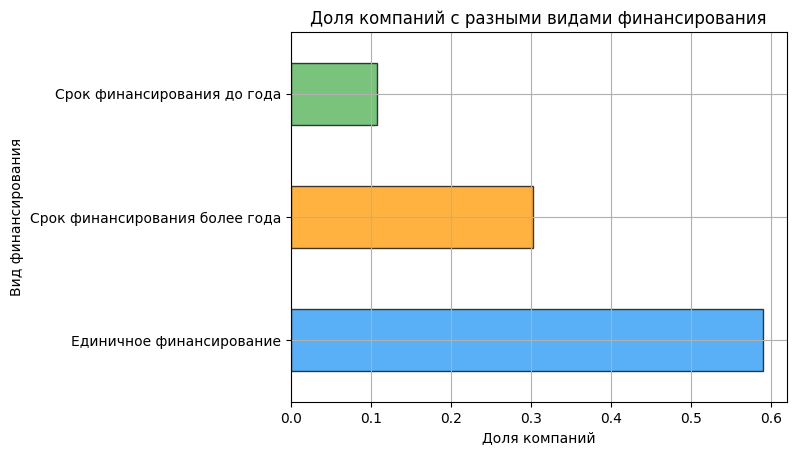

In [35]:
# Задаём цветовую палитру
colors = {
    'Единичное финансирование': '#2196F3',
    'Срок финансирования до года': '#4CAF50',
    'Срок финансирования более года': '#FF9800'
}

# Построим график по количеству компаний (используем палитру для раскрашивания каждой категории в отдельный цвет)
cb_investments['funding_group'].value_counts(normalize=True).plot(kind='barh',
                                alpha=0.75,
                                edgecolor='black',
                                color=[colors[i] for i in cb_investments['funding_group'].value_counts(normalize=True).index])

# Установим название и метки осей
plt.title('Доля компаний с разными видами финансирования')
plt.xlabel('Доля компаний')
plt.ylabel('Вид финансирования')

# Установим сетку
plt.grid()

# Выведем график
plt.show()

Судя по графику, бОльшую часть рынка (почти 60%) занимают компании с единичным финансированием. На втором месте располагаются компании, чьё финансирование продолжается больше года (30%). Компаний же с финансированием до года меньше всего. В связи с этим можно выдвинуть гипотезу, что чаще всего инвесторы предпочитают вкладываться в развитие стартапа разово. Если же они продолжают финансировать компанию, то скорее всего это продлится больше года. Возможно, после единичного финансирования "отваливаются" стартапы, которые не удалось развить.

Теперь посмотрим на компании по количеству инвестиций: какую долю от общего объёма привлечённых средств получила каждая группа.

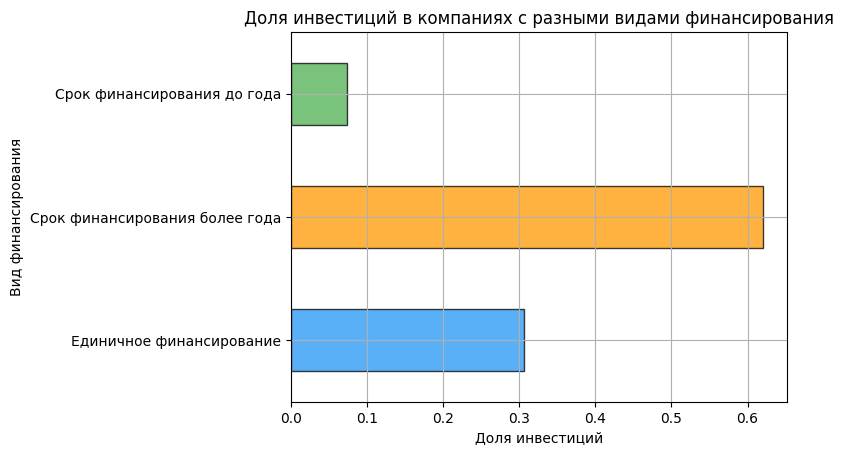

In [36]:
# Посчитаем, сколько средств получила каждая группа 
funding_amount = cb_investments.groupby('funding_group')['funding_total_usd'].sum()

# Переведём в доли
funding_amount = funding_amount / funding_amount.sum()

# Построим график по доле инвестиций для каждой группы (используем палитру для раскрашивания каждой категории в отдельный цвет)
funding_amount.plot(kind='barh',
                    alpha=0.75,
                    edgecolor='black',
                    color=[colors[i] for i in funding_amount.index])

# Установим название и метки осей
plt.title('Доля инвестиций в компаниях с разными видами финансирования')
plt.xlabel('Доля инвестиций')
plt.ylabel('Вид финансирования')

# Установим сетку
plt.grid()

# Выведем график
plt.show()

Несмотря на то, что самих стартапов с единичным финансированием вдвое больше, чем компаний с финансированием более года, больше денег получили именно стартапы второго типа. Их финансирование составило чуть больше 60% от общего финансирования всех трёх типов стартапов. Предположительно это может значить, что при единичном финансировании инвесторы не рискуют и вкладывают не так много денег, как когда уже убедились в том, что стартап рабочий, и продолжают финансировать его развитие.

### 2.2 Выделение средних и нишевых сегментов рынка

<div style="background-color: #fae8b6; padding: 10px;">
    
**Инструкция**

Компании указывают свой сегмент рынка в столбце market. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.
Оставьте в столбце market только массовые сегменты. Для остальных сегментов замените значения на заглушки — niche для нишевых и mid для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.

</div>

In [37]:
# Посчитаем, сколько всего осталось сегментов в столбце market после того как мы устранили неполные дубликаты
print('Количество уникальных сегментов рынка в столбце market: ', cb_investments['market'].nunique())

# Посмотрим, сколько пропусков осталось в этом столбце
print('Количество пропусков в столбце market: ', cb_investments['market'].isna().sum())

# Удалим записи, в которых сегмент рынка неизвестен - так будет проще вести дальнейшую аналитику
cb_investments = cb_investments.dropna(subset=['market'])

Количество уникальных сегментов рынка в столбце market:  394
Количество пропусков в столбце market:  2503


In [38]:
# Рассчитаем, как часто в датасете встречается каждый из сегментов
all_market = cb_investments['market'].value_counts(dropna=False).sort_values(ascending=False).reset_index()
all_market.columns = ['market', 'amount']
print(all_market)

# Посмотрим ещё то же самое, но в доле от всего рынка
all_market_share = cb_investments['market'].value_counts(dropna=False, normalize=True).sort_values(ascending=False).round(2).reset_index()
all_market_share.columns = ['market', 'share']
print(all_market_share)

               market  amount
0            Software    4812
1       Biotechnology    3590
2              Mobile    2344
3          E-Commerce    1866
4         Curated Web    1693
..                ...     ...
389  Natural Gas Uses       1
390               Tea       1
391     IT Management       1
392            Comics       1
393              Gold       1

[394 rows x 2 columns]
               market  share
0            Software   0.13
1       Biotechnology   0.09
2              Mobile   0.06
3          E-Commerce   0.05
4         Curated Web   0.04
..                ...    ...
389  Natural Gas Uses   0.00
390               Tea   0.00
391     IT Management   0.00
392            Comics   0.00
393              Gold   0.00

[394 rows x 2 columns]


Самые популярные сегменты стартапов - Software, Biotechnology и Mobile. Они занимают 13%, 9% и 6% рынка соответственно. За счёт огромного количества сегментов рынка, многие из которых представлены только одной компанией, этот процент не особо большой, но в количественном отношении эти сегменты сильно превосходят другие. 

Поссмотрим по таблице all_market, сколько среди сегментов рынка представителей каждой категории. 

In [39]:
# Создадим функцию, в которой каждому сегменту будет присваиваться категория: массовый, средний или нишевый
def market_category_function(row):
    if row['amount'] > 120:
        return 'mass'
    elif row['amount'] >= 35:
        return 'mid'
    elif row['amount'] < 35:
        return 'niche'
    else:
        return 'unknown'

# Применим функцию к таблице с сегментами
all_market['market_category'] = all_market.apply(market_category_function, axis=1)

# Рассчитаем, сколько сегментов попало в каждую из категорий
print(all_market['market_category'].value_counts().sort_values(ascending=False))

market_category
niche    289
mid       57
mass      48
Name: count, dtype: int64


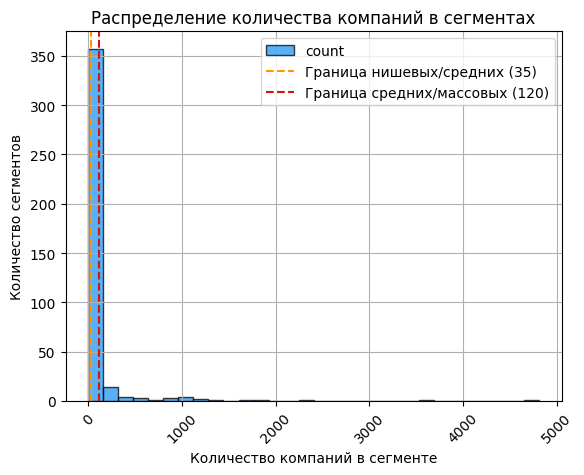

In [40]:
# Построим график распределения сегментов рынка по категориям
cb_investments['market'].value_counts().plot(kind='hist',
                                             alpha=0.75,
                                             edgecolor='black',
                                             color='#2196F3',
                                             rot=45,
                                             bins=30)

# Установим название и метки осей
plt.title('Распределение количества компаний в сегментах')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')

# Добавим линии, которые визуально разделят компании на массовые, средние и нишевые
plt.axvline(x=35, color='#FF9800', label='Граница нишевых/средних (35)', linestyle='--')
plt.axvline(x=120, color='#d41406', label='Граница средних/массовых (120)', linestyle='--')

# Установим сетку
plt.grid()
plt.legend()

# Выведем график
plt.show()

График показывает: на рынке очень много сегментов, в которых маленькое количество компаний. Из таблиц выше мы видели, что есть сегменты, в которых всего по одной компании. Такую закономерность отображает и этот график. Правда, исходя из него, больше всего сегментов вмещает в себя около 30-150 компаний. И лишь в маленьком количестве сегментов количество компаний составляет больше 1000. 

Приблизим график: посмотрим на средние и нишевые сегменты, чтобы увидеть ситуацию детальнее.

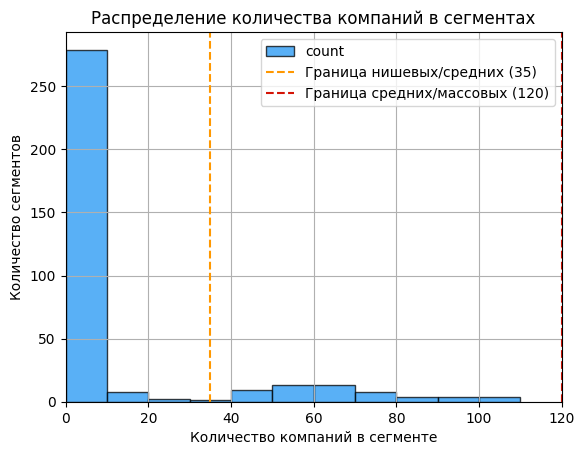

In [41]:
# Построим график распределения сегментов рынка по категориям
cb_investments['market'].value_counts().plot(kind='hist',
                                             alpha=0.75,
                                             edgecolor='black',
                                             color='#2196F3',
                                             bins=range(0, 120, 10))

# Ограничим график только нишевыми и средними сегментами
plt.xlim(0, 120)

# Установим название и метки осей
plt.title('Распределение количества компаний в сегментах')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')

# Добавим линии, которые визуально разделят компании на массовые, средние и нишевые
plt.axvline(x=35, color='#FF9800', label='Граница нишевых/средних (35)', linestyle='--')
plt.axvline(x=120, color='#d41406', label='Граница средних/массовых (120)', linestyle='--')

# Установим сетку
plt.grid()
plt.legend()

# Выведем график
plt.show()

На этом графике тоже видно, что нишевая категория - самая многочисленная. Она состоит из около 300 сегментов, в каждом из которых - единицы компаний (в основном до 10-ти компаний в одном сегменте). Компании по какой-то причине занимают узкие специализированные ниши, и лишь небольшое число сегментов можно назвать средними или массовыми.

Оставим в столбце market только массовые сегменты. Для остальных сегментов заменим значения на заглушки — niche для нишевых и mid для средних. Дальнейшие исследования будем выполнять с учётом этой замены. 

In [42]:
# Объединим таблицу, в которой присвоили сегментам категории, с исходным датафреймом
cb_investments = cb_investments.merge(all_market, how='left', on='market')

# Создадим функцию, которая заменит значения в столбце market на niche и mid в зависимости от категории
def market_plug(row):
    if row['market_category'] == 'niche':
        return 'niche'
    elif row['market_category'] == 'mid':
        return 'mid'
    else:
        return row['market']

# Применим функцию к датасету
cb_investments['market'] = cb_investments.apply(market_plug, axis=1)

# Проверим, что получилось
print(pd.Series(cb_investments['market'].unique()).head(15))
print(pd.Series(cb_investments['market'].unique()).tail(15))

0                     mid
1               Education
2            Social Media
3     Hardware + Software
4           Biotechnology
5             Hospitality
6     Enterprise Software
7           Manufacturing
8                 Finance
9                  Design
10                  niche
11             Nonprofits
12               Software
13            Curated Web
14            Health Care
dtype: object
35                Internet
36                  Sports
37             Photography
38                    News
39                  Search
40               Messaging
41                   Video
42            Marketplaces
43           Entertainment
44                    SaaS
45         Cloud Computing
46                Big Data
47                    Apps
48    Social Network Media
49                Startups
dtype: object


## 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

<div style="background-color: #fae8b6; padding: 10px;">
    
**Инструкция**

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу funding_total_usd графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

</div>

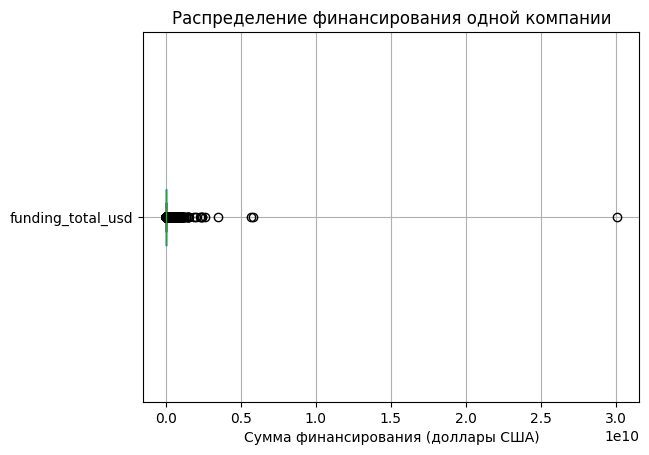

In [43]:
# Построим диаграмму распределения значений ("ящик с усами") для столбца funding_total_usd
cb_investments.boxplot(column='funding_total_usd',
                       vert=False,
                       showfliers=True)

# Установим название и метки осей
plt.title('Распределение финансирования одной компании')
plt.xlabel('Сумма финансирования (доллары США)')

# Выведем диаграмму
plt.show()

📌 "1e10" в правом нижнем углу диаграммы — это научная нотация, означает 10¹⁰ = 10 000 000 000 (10 миллиардов). 

По графику видно, что коробка (основная масса данных) сжата у нуля, а справа — много одиночных выбросов. В том числе один выброс на огромную сумму - 30 миллиардов долларов. Выведем его.

In [44]:
# Пропишем условия и выведем конкретные интересующие нас столбцы
display(cb_investments[cb_investments['funding_total_usd'] > 1*1e10]
    [['name', 'market', 'city', 'funding_total_usd', 'funding_rounds', 'first_funding_at', 'mid_funding_at', 'last_funding_at']])

,name,market,city,funding_total_usd,funding_rounds,first_funding_at,mid_funding_at,last_funding_at
446,Verizon Communications,Mobile,New York,30079503000,5.0,2010-01-26,2012-02-12,2014-02-28


Похоже на правду - это крупная американская компания, так что у неё вполне могло быть такое финансирование. Не будем удалять эту запись из датасета. Но уберём выбросы из графика, чтобы детальнее рассмотреть основной массив данных.

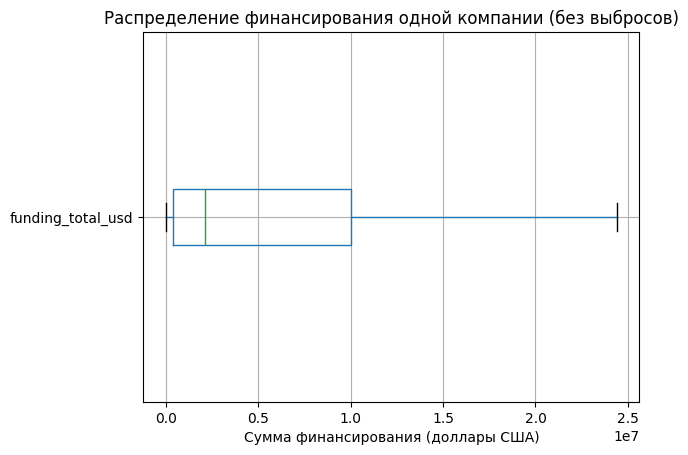

In [45]:
# Построим диаграмму распределения значений ("ящик с усами") для столбца funding_total_usd
cb_investments.boxplot(column='funding_total_usd',
                       vert=False,
                       showfliers=False)

# Установим название и метки осей
plt.title('Распределение финансирования одной компании (без выбросов)')
plt.xlabel('Сумма финансирования (доллары США)')

# Выведем диаграмму
plt.show()

📌 "1e7" в правом нижнем углу диаграммы означает 10⁷ = 10 000 000 (10 миллионов). 

По графику, в среднем финансирование для одной компании распределено от нескольких сотен тысяч до 10 млн долларов. Медиана находится в районе 2 млн долларов, но заметен большой хвост справа - вероятно, это он перетягивает медиану правее. Скорее всего, на практике бОльшую часть компаний финансируют суммами намного меньшими, чем 2 млн долларов. Проверим это, построив по тем же данным гистограмму.

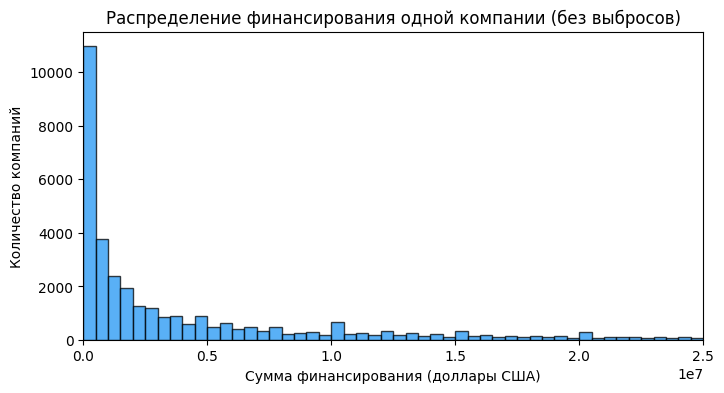

In [46]:
# Отфильтруем значения (это удобно сделать, чтобы не ставить огромное количество bins на графике)
cb_investments_filtered = cb_investments[cb_investments['funding_total_usd'] < 2.5*1e7]

# Построим гистограмму
cb_investments_filtered['funding_total_usd'].plot(kind='hist', 
                                         alpha=0.75,
                                         edgecolor='black',
                                         color='#2196F3',
                                         bins=50,
                                         figsize=(8,4))

# Установим лимит отображения графика
plt.xlim(0, 2.5*1e7)

# Установим название и метки осей
plt.title('Распределение финансирования одной компании (без выбросов)')
plt.xlabel('Сумма финансирования (доллары США)')
plt.ylabel('Количество компаний')

# Выведем диаграмму
plt.show()

Видны более крупные значения в районе круглых сумм - 5 млн, 10 млн, 15 млн, 20 млн. Однако бОльшая часть значений скапливается в промежутке до 2 млн долларов. Самая частая сумма финансирования может оказаться совсем крохотной. Возможно, это всё-таки окажется число-индикатор - одиаковое число, которое ставили везде, где не было данных о финансировании? Приблизим ещё, чтобы понять это.

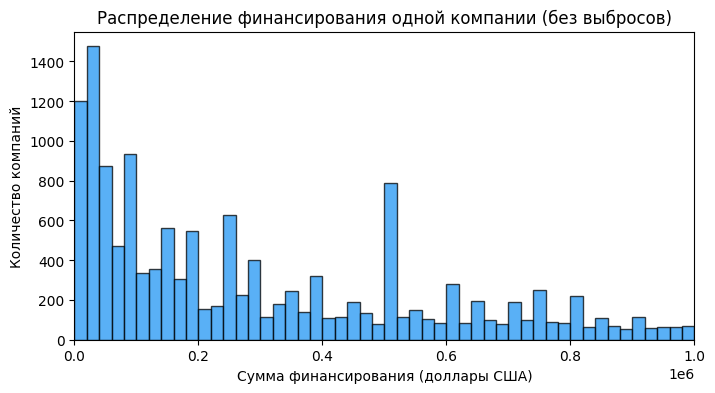

In [47]:
# Снова отфильтруем значения 
cb_investments_filtered_2 = cb_investments[cb_investments['funding_total_usd'] < 1*1e6]

# Построим гистограмму
cb_investments_filtered_2['funding_total_usd'].plot(kind='hist', 
                                         alpha=0.75,
                                         edgecolor='black',
                                         color='#2196F3',
                                         bins=50,
                                         figsize=(8,4))

# Установим лимит отображения графика
plt.xlim(0, 1*1e6)

# Установим название и метки осей
plt.title('Распределение финансирования одной компании (без выбросов)')
plt.xlabel('Сумма финансирования (доллары США)')
plt.ylabel('Количество компаний')

# Выведем диаграмму
plt.show()

Непохоже на то, чтобы здесь было число-индикатор. Видна естественная закономерность: бОльшую часть компаний финансировали небольшими суммами.

Таким образом, по числам можем ориентироваться на наш "ящик с усами" без выбросов: типичным финансированием для одной компании является сумма от нескольких тысяч до 10 млн долларов, а суммы выше этой будут выбиваться.

Посмотрим на эти цифры в разрезе каждого сегмента рынка (при этом все нишевые сегменты у нас объединены в одну группу, а средние — в другую).

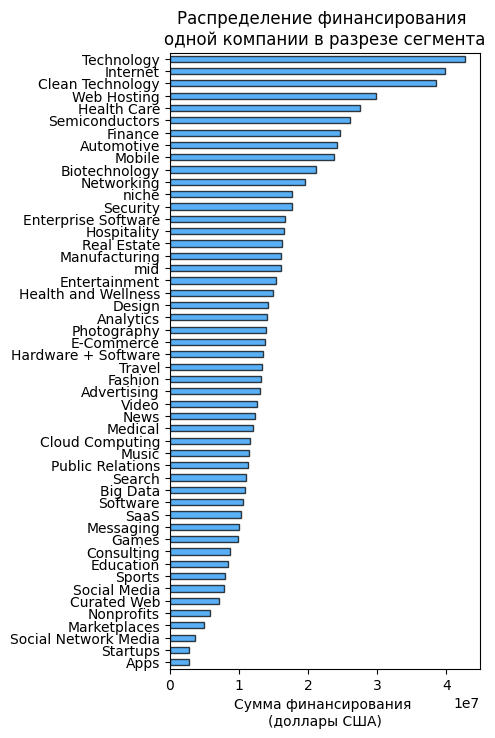

In [48]:
# Сгруппируем данные
cb_investments_grouped = cb_investments[~cb_investments['market'].isna()].groupby(
    'market')['funding_total_usd'].mean().sort_values(ascending=False)

# Построим график по сгруппированным данным
cb_investments_grouped.sort_values(ascending=True).plot(kind='barh',
                                                        alpha=0.75,
                                                        edgecolor='black',
                                                        color='#2196F3',
                                                        figsize=(4,8))

# Установим название и метки осей
plt.title('Распределение финансирования \nодной компании в разрезе сегмента')
plt.xlabel('Сумма финансирования \n(доллары США)')
plt.ylabel('')

# Выведем диаграмму
plt.show()

Самые финансируемые сегменты - Technology, Internet и Clean Technology. Либо они потенцильно самые прибыльные, либо требуют больше вложений. Меньше всего финансируют сегменты Apps, Startups и Social Network Media.

Далее определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту. 

In [50]:
# Создадим пользовательскую функцию, где посчитаем 1 и 3 квартиль и присвоим каждой записи True или False
# в зависимости от того, находится финансирование внутри границ выбросов или снаружи
def outliers(group):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    group['is_outlier'] = ~group['funding_total_usd'].between(lower, upper)
    return group
    
cb_investments = cb_investments.groupby('market', group_keys=False).apply(outliers, include_groups=True)

# Проверим, что получилось
print(cb_investments['is_outlier'].head(15))

0     False
1     False
2     False
3      True
4     False
5     False
6      True
7     False
8     False
9     False
10     True
11     True
12    False
13    False
14     True
Name: is_outlier, dtype: boolean


/var/folders/wx/gd5mkv752w9558dws3m728_00000gn/T/ipykernel_26059/1906743400.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cb_investments = cb_investments.groupby('market', group_keys=False).apply(outliers, include_groups=True)


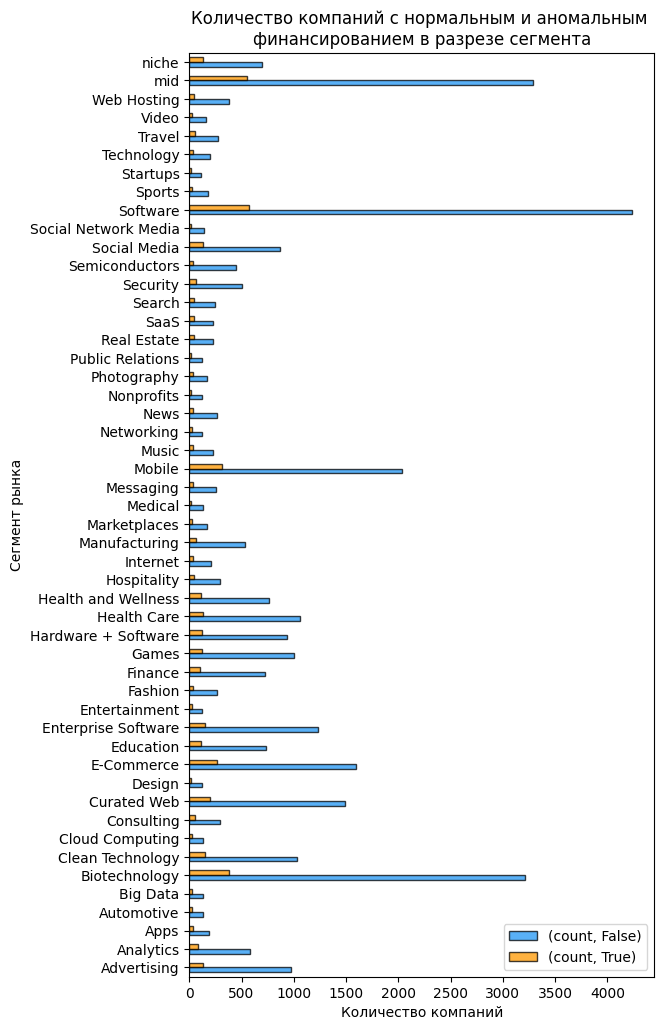

In [52]:
# Сгруппируем данные
cb_investments_in_out = cb_investments.groupby('market')['is_outlier'].value_counts().reset_index()

# Переименуем колонки в получившейся таблице
cb_investments_in_out.columns = ['market', 'is_outlier', 'count']

# Отразим данные на графике
cb_investments_in_out.set_index(['market', 'is_outlier']).sort_values(by='count', ascending=True).unstack().plot(kind='barh', 
                                                                                                   alpha=0.75,
                                                                                                   edgecolor='black',
                                                                                                   color=['#2196F3', '#FF9800'],
                                                                                                   figsize=(6,12))

# Установим название и метки осей
plt.title('Количество компаний с нормальным и аномальным \nфинансированием в разрезе сегмента')
plt.xlabel('Количество компаний')
plt.ylabel('Сегмент рынка')

# Установим легенду
plt.legend()

# Выведем диаграмму
plt.show()

График показывает, что в подавляющем большинстве компаний мало выбросов по финансированию. Однако больше всего их в таких сегментах: Software, mid и Biotechnology. 

Посмотрим только на выбросы. Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование.

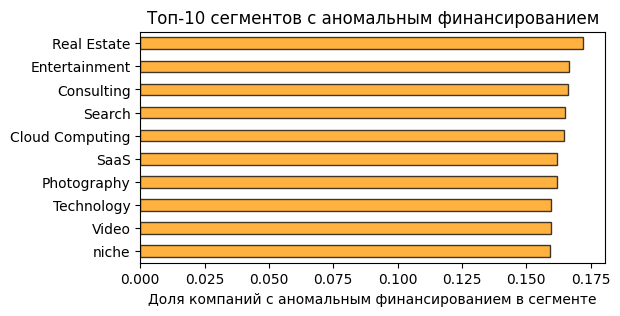

In [53]:
# Сгруппируем данные по аналогии с прошлым разом, но уже с отображением относительных, а не абсолютных значений
cb_investments_in_out_share = cb_investments.groupby('market')['is_outlier']\
    .value_counts(normalize=True)\
    .reset_index()

# Переименуем столбцы в новой таблице
cb_investments_in_out_share.columns = ['market', 'is_outlier', 'share']

# Оставим компании только с аномальным финансированием и отсортируем их в порядке убывания по доле аномального финансирования
cb_investments_outliers = cb_investments_in_out_share[cb_investments_in_out_share['is_outlier'] == True]
cb_investments_outliers_share = cb_investments_outliers.sort_values(by='share', ascending=False)

# Построим график только из сегментов компаний с аномальным финансированием
cb_investments_outliers_share.head(10).sort_values(by='share', ascending=True).plot(kind='barh', 
                                                                      x='market',
                                                                      y='share',
                                                                      alpha=0.75,
                                                                      edgecolor='black',
                                                                      color='#FF9800',
                                                                      figsize=(6,3),
                                                                      legend=False)

# Установим название и метки осей
plt.title('Топ-10 сегментов с аномальным финансированием')
plt.xlabel('Доля компаний с аномальным финансированием в сегменте')
plt.ylabel('')

# Выведем диаграмму
plt.show()

На графике показано, что выбросов больше всего в сферах недвижимости, развлечений, консалтинга и некоторых других. Возможно, инвесторы находят эти сегменты рынка достаточно прибыльными, чтобы инвестировать туда больше денег.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

<div style="background-color: #fae8b6; padding: 10px;">
    
**Инструкция**

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов mid_funding_at и funding_rounds оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

</div>

In [54]:
# Проверим уникальные месяцы 2014 года, за которые в датасете есть данные
print('Месяцы 2014 года в столбце first_funding_at: ', 
      cb_investments[~cb_investments['first_funding_at'].isna()]['first_funding_at']\
      .dt.month.sort_values().unique())

print('Месяцы 2014 года в столбце last_funding_at: ', 
      cb_investments['last_funding_at']\
          .dt.month.sort_values().unique())

Месяцы 2014 года в столбце first_funding_at:  [ 1  2  3  4  5  6  7  8  9 10 11 12]
Месяцы 2014 года в столбце last_funding_at:  [ 1  2  3  4  5  6  7  8  9 10 11 12]


Данные в обоих столбцах представлены за все месяцы 2014 года.

In [55]:
# Оставим в датасете только данные о компаниях с нормальным финансированием
# В инструкции сказано "исключите компании с аномальным финансированием", но таблица, которую мы получили по аномальному финансированию,
# была в разрезе сегментов, а не компаний, поэтому здесь нам приётся просто наоборот исключить записи с аномальным финансированием
cb_investments_inliers = cb_investments[cb_investments['is_outlier'] == False].copy()

# Посчитаем количество раундов финансирования отдельно по каждому году (используем столбец с годом, который создали в процессе предобработки)
rounds_count = cb_investments_inliers.groupby('mid_funding_at_year')['funding_rounds'].sum().reset_index()
rounds_count.columns = ['mid_funding_at_year', 'rounds_sum']

# Присоединим получишийся результат к датафрейму в отдельный столбец
cb_investments_inliers = cb_investments_inliers.merge(rounds_count, how='left', on='mid_funding_at_year').copy()

# И выведем только те компании, которые получали финансирование в годы, когда было зафиксировано 50 или более раундов 
companies_over_50_rounds = cb_investments_inliers[cb_investments_inliers['rounds_sum'] > 50].copy()
display(companies_over_50_rounds[['name', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'rounds_sum']].head())
print('Количество компаний, которые получили финансирование в годы, когда было зафиксировано 50 или более раундов: ', 
      companies_over_50_rounds.shape[0])

,name,first_funding_at,mid_funding_at,last_funding_at,rounds_sum
0,DuPont,2009-07-02,2009-07-02,2009-07-02,4472.0
1,University of Michigan,2013-11-21,2013-11-21,2014-11-03,12320.0
2,Case Western Reserve University,2014-01-14,2014-01-14,2014-01-14,6343.0
3,Duke University,2014-01-12,2014-01-12,2014-01-12,6343.0
4,WeGame,2007-10-01,2007-10-01,2008-03-01,2820.0


Количество компаний, которые получили финансирование в годы, когда было зафиксировано 50 или более раундов:  33472


### 3.3. Анализ типов финансирования по объёму и популярности

<div style="background-color: #fae8b6; padding: 10px;">
    
**Инструкция**

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market и product_crowdfunding.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

</div>

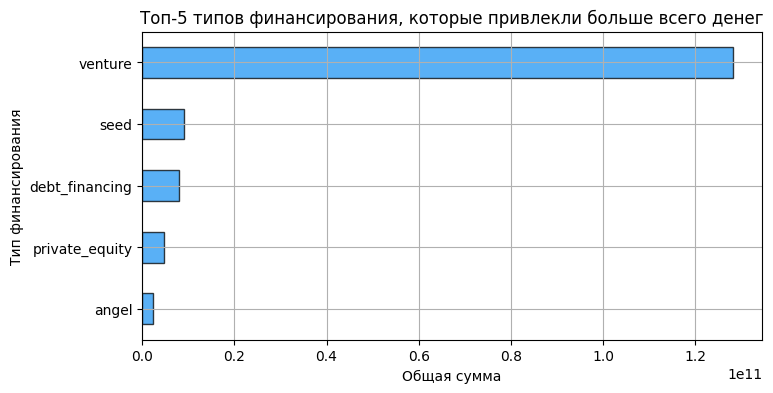

In [56]:
# Создадим отдельный датафрейм, где будут только данные, связанные с типами финансирования
funding_types = companies_over_50_rounds[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                                          'convertible_note', 'debt_financing', 'angel', 'grant', 
                                          'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                                          'secondary_market', 'product_crowdfunding']].copy()

# Посчитаем сумму значений в каждом столбце, где есть информация о разных типах финансирования, и отсортируем их в порядке убывания
funding_types_sum = funding_types.sum().sort_values(ascending=False)

# Построим график по этим данным
funding_types_sum.head().sort_values(ascending=True).plot(kind='barh', 
                                                          alpha=0.75,
                                                          edgecolor='black',
                                                          color='#2196F3',
                                                          figsize=(8,4),
                                                          grid=True)

# Установим название и метки осей
plt.title('Топ-5 типов финансирования, которые привлекли больше всего денег')
plt.xlabel('Общая сумма')
plt.ylabel('Тип финансирования')

# Выведем график
plt.show()

📌"1e11" в правом нижнем углу — это 100 000 000 000 (100 миллиардов).

Получается, венчурные инвестиции составили около 130 млрд долларов - это самый крупный тип финансирования. Венчурные инвестиции - это долгосрочные вложения капитала в молодые, технологичные стартапы с высоким потенциалом быстрого роста (взрывного роста). Главная особенность - высокий риск (более 50% стартапов прогорают), который компенсируется кратной прибылью от единичных успешных проектов. Остальные типы финансирования очень значительно отстают в объёмах от венчурных инвестиций.

Ограничим график, чтобы детальнее рассмотреть остальные типы.

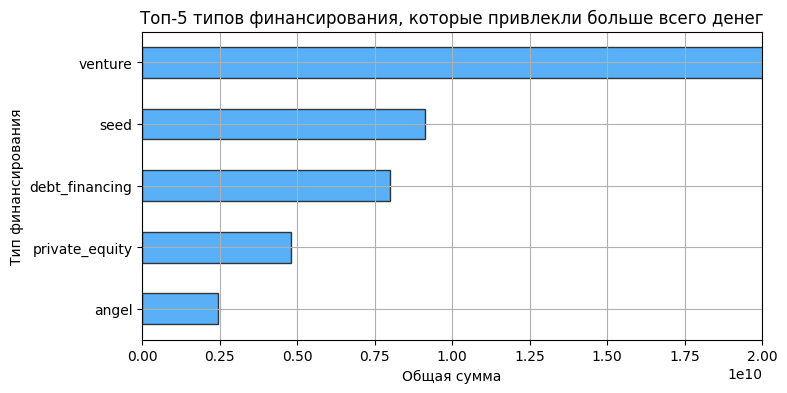

In [57]:
# Построим график
funding_types_sum.head().sort_values(ascending=True).plot(kind='barh', 
                                                          alpha=0.75,
                                                          edgecolor='black',
                                                          color='#2196F3',
                                                          figsize=(8,4),
                                                          grid=True)

# Установим название и метки осей
plt.title('Топ-5 типов финансирования, которые привлекли больше всего денег')
plt.xlabel('Общая сумма')
plt.ylabel('Тип финансирования')

# Установим лимит для оси Х
plt.xlim(0, 0.2*1e11)

# Выведем график
plt.show()

📌"1e10" в правом нижнем углу — это 10 000 000 000 (10 миллиардов).

Остальные 4 флагманских типа финансирования составили от 2,5 млрд до 8 млрд долларов.

Теперь построим график, который покажет популярность разных типов финансирования - какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

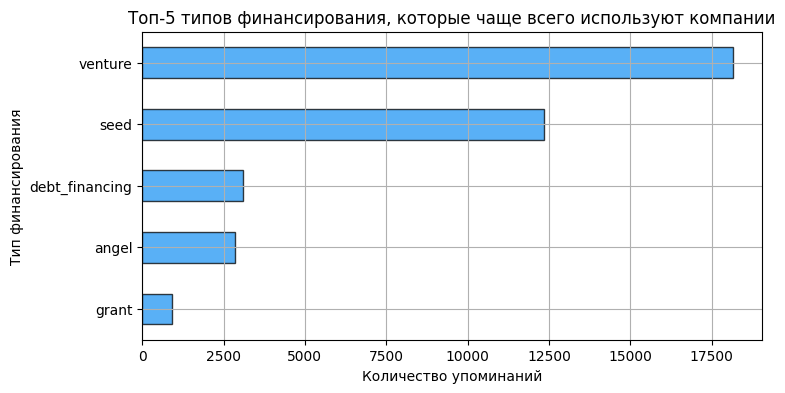

In [58]:
# Заменим все 0 на NaN и посчитаем количество оставшихся записей
funding_types_count = funding_types.replace(0, None).count().sort_values(ascending=False)

# Построим график по этим данным
funding_types_count.head().sort_values(ascending=True).plot(kind='barh',
                                                            alpha=0.75,
                                                            edgecolor='black',
                                                            color='#2196F3',
                                                            figsize=(8,4),
                                                            grid=True)

# Установим название и метки осей
plt.title('Топ-5 типов финансирования, которые чаще всего используют компании')
plt.xlabel('Количество упоминаний')
plt.ylabel('Тип финансирования')

# Выведем график
plt.show()

Венчурные инвестиции и тут оказались на первом месте.

Сравним эти графики. Выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [59]:
# Дадим названия столбцам датафреймов, которые создали ранее
funding_types_sum = pd.DataFrame(funding_types_sum.reset_index())
funding_types_sum.columns = ['market', 'market_sum']

funding_types_count = pd.DataFrame(funding_types_count.reset_index())
funding_types_count.columns = ['market', 'market_count']

# Объединим два датафрейма в один
funding_types_all = funding_types_sum.merge(funding_types_count, how='outer', on='market')

,market,market_sum_norm,market_count_norm
12,venture,0.802376,0.452477
10,seed,0.057066,0.308063
2,debt_financing,0.050175,0.077259
7,private_equity,0.030133,0.015417
0,angel,0.015277,0.071396
11,undisclosed,0.012741,0.018485
6,post_ipo_equity,0.012165,0.004066
4,grant,0.011982,0.022901
1,convertible_note,0.003448,0.012498
5,post_ipo_debt,0.001796,0.000674


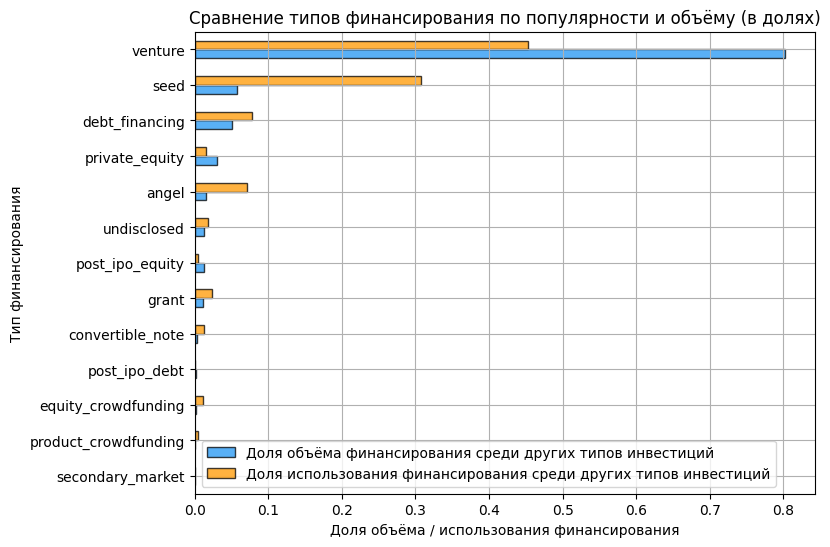

In [60]:
# Нормализуем значения датафреймов, вычислив долю каждого значения от суммы всех значений 
# (мы это делаем, так как порядок величин абсолютно разный, а нам надо иметь возможность сравнить их) 
funding_types_all['market_sum_norm'] = funding_types_all['market_sum'] / funding_types_all['market_sum'].sum()
funding_types_all['market_count_norm'] = funding_types_all['market_count'] / funding_types_all['market_count'].sum()

# Выведем данные
display(funding_types_all[['market', 'market_sum_norm', 'market_count_norm']].sort_values(by='market_sum_norm', ascending=False))

# Построим объединённый график
funding_types_all.sort_values(by='market_sum_norm', ascending=True).plot(kind='barh',
                                                                 x='market',
                                                                 y=['market_sum_norm', 'market_count_norm'],
                                                                 alpha=0.75,
                                                                 edgecolor='black',
                                                                 color=['#2196F3', '#FF9800'],
                                                                 figsize=(8,6),
                                                                 grid=True)

# Установим название и метки осей
plt.title('Сравнение типов финансирования по популярности и объёму (в долях)')
plt.xlabel('Доля объёма / использования финансирования')
plt.ylabel('Тип финансирования')

# Установим легенду
plt.legend(['Доля объёма финансирования среди других типов инвестиций', 
            'Доля использования финансирования среди других типов инвестиций'])

# Выведем график
plt.show()

По этому графику уже можно сделать выводы, но приблизим его, чтобы увидеть, что происходит у маленьких значений.

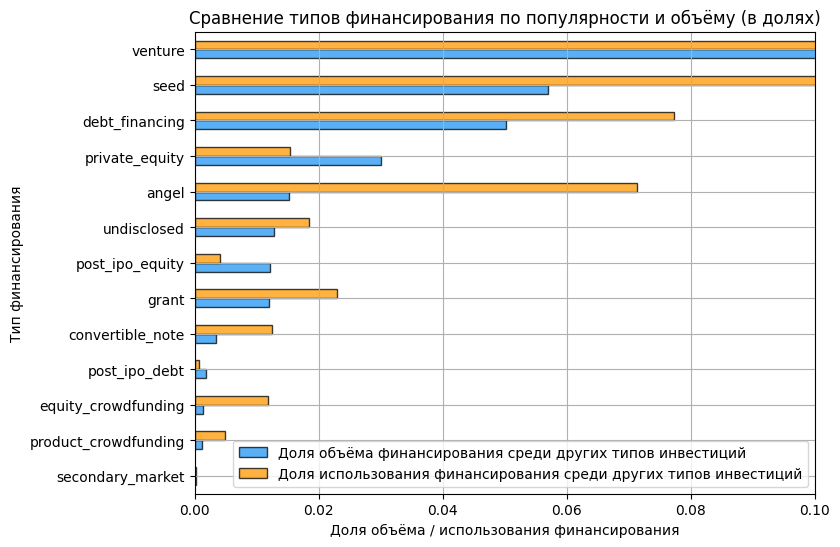

In [61]:
# Построим объединённый график
funding_types_all.sort_values(by='market_sum_norm', ascending=True).plot(kind='barh',
                                                                 x='market',
                                                                 y=['market_sum_norm', 'market_count_norm'],
                                                                 alpha=0.75,
                                                                 edgecolor='black',
                                                                 color=['#2196F3', '#FF9800'],
                                                                 figsize=(8,6),
                                                                 grid=True)

# Установим лимит для оси X
plt.xlim(0, 0.1)

# Установим название и метки осей
plt.title('Сравнение типов финансирования по популярности и объёму (в долях)')
plt.xlabel('Доля объёма / использования финансирования')
plt.ylabel('Тип финансирования')

# Установим легенду
plt.legend(['Доля объёма финансирования среди других типов инвестиций', 
            'Доля использования финансирования среди других типов инвестиций'])

# Выведем график
plt.show()

По графикам видно, что венчурные инвестиции лидируют в обоих отношениях. При этом доля объёма значительно превышает долю использования: это говорит о том, что суммы каждой инвестиции очень крупные. Из более редких типов такая особенность есть у двух типов финансирования: private_equity (прямые инвестиции, это вложение капитала в частные компании, акции которых не торгуются на бирже) и post_ipo_equity (акции после IPO, это обыкновенные акции компании, которые стали доступны для свободной торговли на бирже после завершения первичного публичного размещения (IPO)). 

Отдельно можно заметить особенность seed-инвестиций — они используются часто, но при этом небольшие по объёму. (Seed-инвестиции - это ранний этап финансирования стартапа, направленный на разработку MVP, проверку бизнес-модели и первые продажи.) Вероятно, так происходит потому, что на раннем этапе не нужны большие деньги для запуска продукта, при этом это хороший способ протестировать жизнеспособность стартапа. 

Такая же особенность, но в меньшей степени, есть у бизнес-ангелов (частные венчурные инвесторы, которые тоже вкладываются в стартап на ранних стадиях развития) и долгового финансирования (это кредиты, облигационные займы, ипотека). Из тех типов, что используются реже и их объёмы меньше, такое присуще краудфандингу (это коллективный сбор денежных средств на определенную цель, проект или бизнес-идею) и конвертируему заёму (популярный инструмент венчурного финансирования, сочетающий черты долга и инвестиции в капитал).

На основании этого можно предположить, что компании часто используют помощь инвесторов именно на ранних этапах развития, при этом от инвесторов не требуются большие суммы. А венчурные, прямые инвестиции и акции после IPO, напротив, характеризуются большими суммами.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период. Используем второй датасет cb_returns.

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

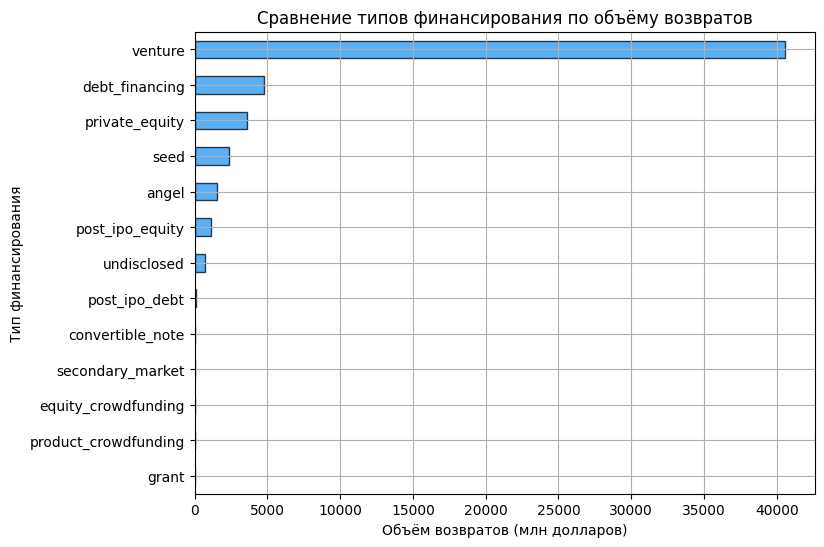

In [62]:
# Посчитаем суммарный объём возвратов в разных типах финансирования
cb_returns_sum = cb_returns.sum().sort_values(ascending=False)

# Выведем его
display(cb_returns_sum)

# Построим график по этим данным
cb_returns_sum.sort_values(ascending=True).plot(kind='barh',
                                                alpha=0.75,
                                                edgecolor='black',
                                                color='#2196F3',
                                                figsize=(8,6),
                                                grid=True)

# Установим название и метки осей
plt.title('Сравнение типов финансирования по объёму возвратов')
plt.xlabel('Объём возвратов (млн долларов)')
plt.ylabel('Тип финансирования')

# Выведем график
plt.show()

Венчурные инвестиции доминируют и по объёму вложений, и по возвратам. Само по себе это не говорит о высокой доходности - это может просто отражать масштаб. Интересно сравнить пропорции: если венчур занимает, допустим, 40% всех вложений, но 85% всех возвратов - это хороший знак. Если наоборот - плохой.

venture                 0.740961
debt_financing          0.086458
private_equity          0.065504
seed                    0.043499
angel                   0.027558
post_ipo_equity         0.020176
undisclosed             0.013346
post_ipo_debt           0.001662
convertible_note        0.000635
secondary_market        0.000095
equity_crowdfunding     0.000070
product_crowdfunding    0.000034
grant                   0.000000
dtype: float64

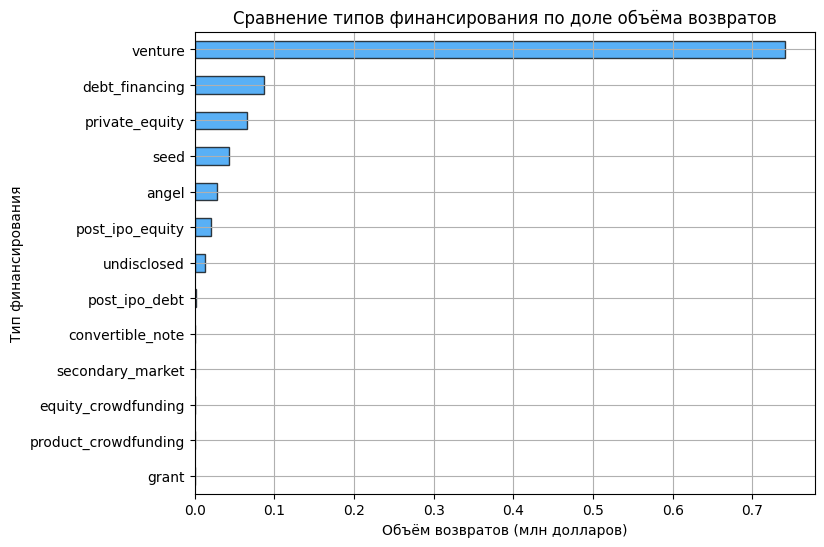

In [63]:
# Посчитаем доли возвратов
cb_returns_share = cb_returns_sum / cb_returns_sum.sum()

# Выведем их
display(cb_returns_share)

# Построим график 
cb_returns_share.sort_values(ascending=True).plot(kind='barh',
                                                alpha=0.75,
                                                edgecolor='black',
                                                color='#2196F3',
                                                figsize=(8,6),
                                                grid=True)

# Установим название и метки осей
plt.title('Сравнение типов финансирования по доле объёма возвратов')
plt.xlabel('Объём возвратов (млн долларов)')
plt.ylabel('Тип финансирования')

# Выведем график
plt.show()

Здесь можно заметить большую прибыльность венчурных инвестиций: при объёме 45% от всех вложений он приносит доходность в 74%. Можем сделать вывод, что это наиболее рекомендуемый тип финансирования, который следует выбрать нашим инвесторам.

## 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

<div style="background-color: #fae8b6; padding: 10px;">
    
**Инструкция**

Используя столбцы funding_total_usd и funding_rounds, для каждой компании рассчитайте средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, которые отразят:
- динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;
- динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
- В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?
- Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

</div>

    mid_funding_at_year  avg_funding_per_round
0                2000.0          4757171.35324
1                2001.0         3945237.903736
2                2002.0         4134553.552009
3                2003.0         3221102.014167
4                2004.0         4905335.018885
5                2005.0          5887842.16473
6                2006.0         5405702.923347
7                2007.0         4712847.730945
8                2008.0         4374561.841197
9                2009.0         3643193.026732
10               2010.0         3279352.959287
11               2011.0         2676829.100285
12               2012.0         2139801.321564
13               2013.0          2075542.84146
14               2014.0         2395303.890426


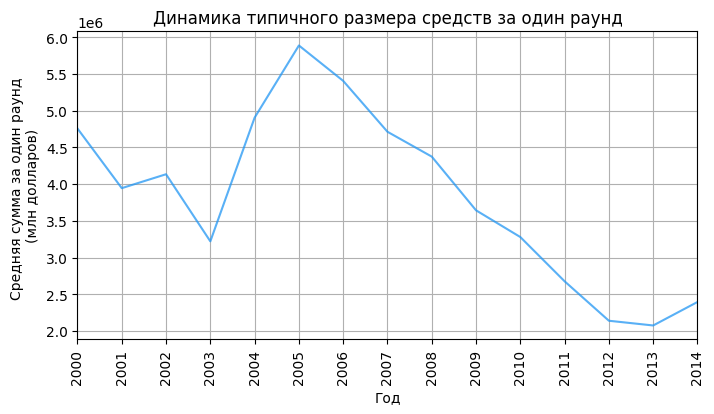

In [64]:
# Используем данные после предыдущих фильтраций, то есть датафрейм companies_over_50_rounds
# Создадим для него новый столбец с подсчётом средней суммы за один раунд финансирования
companies_over_50_rounds['avg_funding_per_round'] = \
companies_over_50_rounds['funding_total_usd'] / companies_over_50_rounds['funding_rounds']

# Сгруппируем данные, чтобы получился новый датафрейм с годами и средней суммы за один раунд финансирования одной компании
df_avg_funding_per_round = companies_over_50_rounds.groupby('mid_funding_at_year')['avg_funding_per_round'].mean().reset_index()

# Выведем данные 
print(df_avg_funding_per_round)

# Построим график по этим данным
df_avg_funding_per_round.set_index('mid_funding_at_year').plot(kind='line',
                              alpha=0.75,
                              color='#2196F3',
                              figsize=(8,4),
                              grid=True,
                              legend=False)

# Установим название и метки осей
plt.title('Динамика типичного размера средств за один раунд')
plt.xlabel('Год')
plt.ylabel('Средняя сумма за один раунд \n(млн долларов)')

# Установим лимит по оси X
plt.xlim(2000, 2014)

# Установим на оси X все года из датасета
plt.xticks(df_avg_funding_per_round['mid_funding_at_year'], rotation=90)

# Выведем график
plt.show()

📌"1e6" в левом верхнем углу - это 1 000 000 (1 миллион).

    mid_funding_at_year  rounds_sum
0                1960.0         2.0
1                1979.0         1.0
2                1984.0         2.0
3                1987.0         1.0
4                1989.0         1.0
5                1990.0         1.0
6                1992.0         2.0
7                1993.0         1.0
8                1994.0         3.0
9                1995.0         9.0
10               1996.0         8.0
11               1997.0         5.0
12               1998.0        15.0
13               1999.0        41.0
14               2000.0       109.0
15               2001.0        58.0
16               2002.0        97.0
17               2003.0       120.0
18               2004.0       169.0
19               2005.0       931.0
20               2006.0      1825.0
21               2007.0      2820.0
22               2008.0      3624.0
23               2009.0      4472.0
24               2010.0      5975.0
25               2011.0      7364.0
26               2012.0     

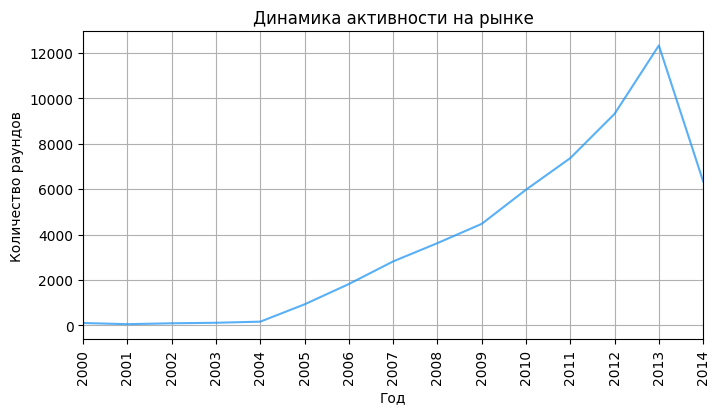

In [65]:
# Используем таблицу rounds_count, которую создавали ранее. Выведем данные
print(rounds_count)

# Построим линейный график
rounds_count.set_index('mid_funding_at_year').plot(kind='line',
                                                   alpha=0.75,
                                                   color='#2196F3',
                                                   figsize=(8,4),
                                                   grid=True,
                                                   legend=False)

# Установим название и метки осей
plt.title('Динамика активности на рынке')
plt.xlabel('Год')
plt.ylabel('Количество раундов')

# Установим на оси X все года из датасета
plt.xticks(rounds_count['mid_funding_at_year'], rotation=90)

# Установим лимит по оси X, так как до 2000-х активность была минимальной
plt.xlim(2000, 2014)

# Выведем график
plt.show()

Отвечаем на вопросы:

- В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

В 2005 году - почти 5,9 млн долларов.
  
- Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

В 2014 году раундов было больше 6 тысяч, а в рамках каждого раунда выделялось в среднем 2,4 млн долларов.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

<div style="background-color: #fae8b6; padding: 10px;">
    
**Инструкция**

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования funding_total_usd по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

</div>

In [66]:
# Составим сводную таблицу, используя датафрейм с компаниями, которые финансировались в годы, где было больше 50 раундов
funding_table = pd.pivot_table(companies_over_50_rounds,
                               values='funding_total_usd',
                               index='mid_funding_at_year',
                               columns='market',
                               aggfunc='sum',
                               fill_value=0)

# Отберём из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013
mask = funding_table.loc[2014.0] > funding_table.loc[2013.0]
funding_table_grow = funding_table[funding_table.columns[mask]]

# Выведем получившуюся таблицу
display(funding_table_grow)

market,Apps,Big Data,Design,Internet,Manufacturing,Medical,Real Estate,SaaS,Startups,Technology,mid,niche
mid_funding_at_year,,,,,,,,,,,,
2000.0,0,0,0,10000000,56659310,24000000,2500000,0,0,0,82440389,14600000
2001.0,0,0,0,0,2368582,0,0,0,0,22160000,9441026,24020000
2002.0,0,0,0,1100000,0,0,5275000,2000000,0,11000000,18885799,0
2003.0,0,0,0,0,4269608,0,6292200,0,0,0,43238404,0
2004.0,0,0,0,10500000,3000000,0,0,0,0,1750000,54438160,0
2005.0,0,0,9300000,1775000,61770000,11090000,250000,5240000,0,50728425,214407455,0
2006.0,1310600,0,707000,5000,163957751,20250000,2080000,4791121,0,22791000,347522579,11180000
2007.0,0,7780000,10800000,4495379,147726051,2100000,33220000,14652595,0,180190209,503542893,44494637
2008.0,4300000,2452515,5944302,23412964,173054260,28812744,46613100,27226900,5010387,277726238,550374758,22279331


До 2008 года в данных попадаются пропуски. Возьмём данные за 2008+ годы и посмотрим на графике, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам.

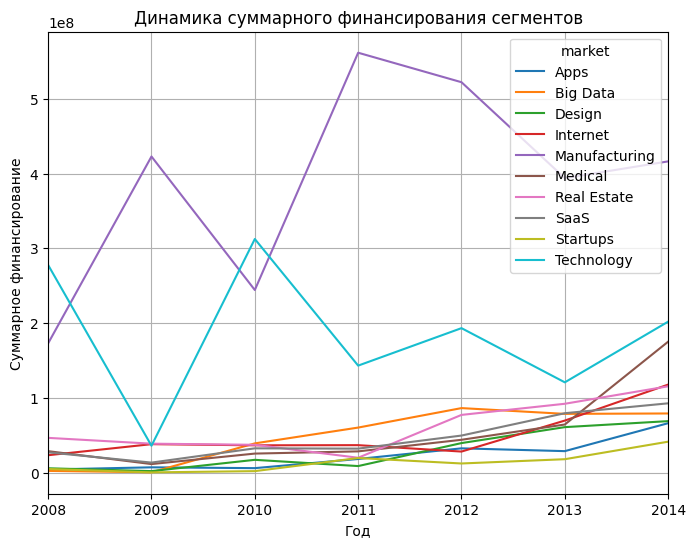

In [67]:
# Поменяем для удобства тип данных у годов 
funding_table_grow.index = funding_table_grow.index.astype('int64')

# Построим график
funding_table_grow.drop(columns=['mid', 'niche']).plot(kind='line',
                        legend=True,
                        figsize=(8,6),
                        grid=True)

# Установим название и метки осей
plt.title('Динамика суммарного финансирования сегментов')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование')

# Установим лимит по оси X, так как до 2000-х активность была минимальной
plt.xlim(2008, 2014)

# Выведем график
plt.show()

Наиболее быстрый и уверенный рост с 2013 года показывают отрасли Medical, Apps и Internet.

Отрасль Technology также показывает быстрый рост, но при этом она достаточно сильно колебалась ранее.

Отрасли Manufacturing, несмотря на её высокие показатели,  вряд ли стоит доверять, так как она невероятно сильно колеблется.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

<div style="background-color: #fae8b6; padding: 10px;">
    
**Инструкция**

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например, 1e-60. Это поможет избежать деления на ноль.

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования venture, debt_financing, private_equity, seed и angel.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

</div>

In [68]:
# Составим список столбцов, которые относятся к типам финансирования, в нашем исходном датафрейме
funding_cols = ['seed', 'venture', 'angel', 'grant', 'debt_financing', 
                 'convertible_note', 'equity_crowdfunding', 'undisclosed',
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt',
                 'secondary_market', 'product_crowdfunding']

# Сгруппируем данные по году и высчитаем сумму значений в столбцах
investments_by_year = cb_investments.groupby('mid_funding_at_year')[funding_cols].sum()

# Приведём года из таблицы к типу int
investments_by_year.index = investments_by_year.index.astype('int64')

# Считаем, какую долю возвращённые средства составляют от предоставленных (при этом учитываем разницу в единицах измерения двух таблиц)
return_ratio = round((cb_returns * 1e6) / (investments_by_year + 1e-60),4)

# Заменяем долю больше 1 на NaN
return_ratio[return_ratio > 1] = None

# Отсекаем лишние года, которых нет в таблице cb_returns
return_ratio = return_ratio[return_ratio.index >= 2000]

# Выводим получившуюся таблицу
display(return_ratio)

,angel,convertible_note,debt_financing,equity_crowdfunding,grant,post_ipo_debt,post_ipo_equity,private_equity,product_crowdfunding,secondary_market,seed,undisclosed,venture
2000,0.2465,0.0000,0.1261,0.0000,0.0,0.0000,0.2711,0.0000,0.0000,0.0259,0.3996,0.2382,0.0283
2001,NaN,0.0067,0.0729,0.0000,0.0,0.0000,NaN,0.0000,0.0000,NaN,NaN,0.0961,0.0209
2002,0.4262,NaN,0.0159,0.0000,0.0,0.0000,NaN,0.0014,0.0000,NaN,0.3616,0.2938,0.2024
2003,0.0710,0.0067,0.0512,0.0000,0.0,0.0000,0.0258,0.0584,0.0000,NaN,0.4465,0.9144,0.1173
2004,0.7939,NaN,0.0825,0.0000,0.0,0.0000,NaN,0.0127,0.0000,NaN,0.3150,0.5583,0.1512
2005,0.4818,NaN,0.0468,0.0000,0.0,0.0000,0.0020,0.0018,0.0000,0.0004,0.5676,0.3833,0.2105
2006,0.5319,0.0610,0.0352,NaN,0.0,0.0000,0.1091,0.0069,0.0000,0.0019,0.5999,0.2461,0.1336
2007,0.6346,0.1433,0.0516,NaN,0.0,0.0000,0.0178,0.0108,0.0000,NaN,0.2428,0.1949,0.0933
2008,0.3734,0.0443,0.0754,NaN,0.0,0.0000,0.0591,0.0120,0.0000,NaN,0.2534,0.0724,0.0517
2009,0.4528,0.0195,0.0714,0.0878,0.0,0.0000,0.0130,0.0185,0.0660,0.0003,0.2881,0.1160,0.0478


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования venture, debt_financing, private_equity, seed и angel.

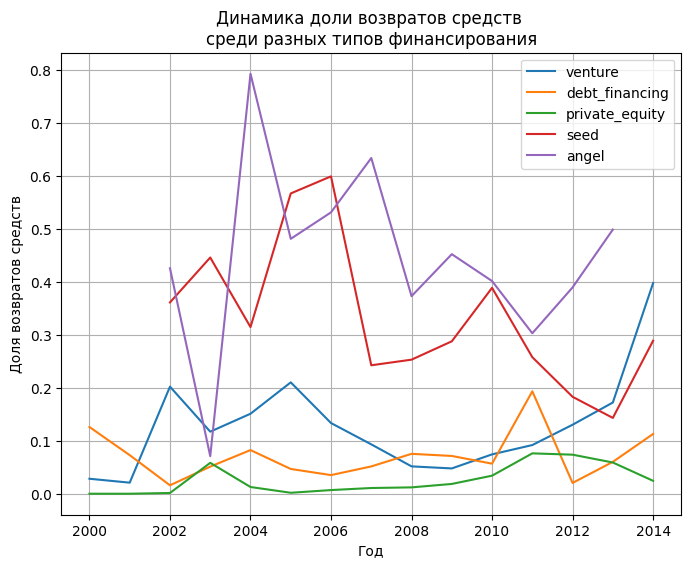

In [69]:
cols_to_plot = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

return_ratio[cols_to_plot].plot(kind='line',
                                legend=True,
                                figsize=(8,6),
                                grid=True)

# Установим название и метки осей
plt.title('Динамика доли возвратов средств \nсреди разных типов финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возвратов средств')

# Выведем график
plt.show()

Судя по графику, наиболее устойчивый рост показателя наблюдается у венчурных инвестиций (venture). 

## 5. Итоговый вывод и рекомендации

#### Что мы сделали

Мы исследовали рынок венчурного финансирования стартапов на основе двух датасетов: данных о компаниях и привлечённых инвестициях (cb_investments) и данных о возвратах средств по типам финансирования (cb_returns).

Сначала мы привели данные в порядок: изменили типы столбцов, убрали дубликаты и пропуски, в том числе восстановили пропущенные даты среднего раунда финансирования на основе первого и последнего. В итоге мы удалили около 25% данных, но оставшегося было достаточно для анализа.

Затем мы разделили компании на группы по срокам финансирования и классифицировали сегменты рынка на массовые, средние и нишевые. После этого выявили выбросы по объёму финансирования методом IQR — отдельно по каждому сегменту — и исключили аномальные компании из дальнейшего анализа. Также мы ограничили период исследования годами, в которых фиксировалось не менее 50 раундов финансирования.

Дальше мы сравнили типы финансирования по объёму и популярности, посмотрели на динамику раундов и среднего размера вложений по годам, проследили рост финансирования в разрезе сегментов рынка и рассчитали долю возврата средств по каждому типу финансирования.

#### Главные находки

**Структура рынка по типу компаний.** Почти 60% компаний получили финансирование только один раз. При этом компании с долгосрочным финансированием (более года) привлекли больше 60% всех денег, хотя их самих вдвое меньше. Это говорит о том, что инвесторы осторожно входят в проект, а если продолжают вкладываться — то уже серьёзно.

**Сегменты рынка.** Самые крупные массовые сегменты — Software, Biotechnology и Mobile. Больше всего денег на одну компанию получают Technology, Internet и Clean Technology. Самую высокую долю аномального финансирования показывают недвижимость, развлечения и консалтинг.

**Типы финансирования.** Венчурные инвестиции лидируют и по объёму (около 130 млрд долларов), и по популярности. При этом при доле вложений около 45% они дают 74% всех возвратов — это говорит о том, что венчур эффективнее остальных типов в пересчёте на отдачу. Seed-инвестиции часто используются, но суммы в них небольшие — это логично для ранней стадии. Private equity и post-IPO equity встречаются реже, но суммы крупные.

**Динамика рынка.** Пик среднего размера одного раунда финансирования пришёлся на 2005 год — почти 5,9 млн долларов. К 2014 году средний раунд снизился до 2,4 млн, зато количество раундов резко выросло — больше 6 тысяч за год. Рынок стал массовее, но раунды — меньше.
Растущие сегменты. Среди массовых сегментов наиболее уверенный рост финансирования к 2014 году показывают Medical, Apps и Internet. Technology тоже растёт быстро, но с заметными колебаниями. Manufacturing показывает высокие цифры, но слишком нестабильна, чтобы на неё опираться.

**Возврат средств.** Наиболее устойчивый рост доли возврата среди всех рассмотренных типов показывают венчурные инвестиции.

#### Рекомендации

Для финансовой компании, которая принимает инвестиционное решение в 2015 году, опираясь на эти данные, мы бы рекомендовали следующее.

**Делать ставку на венчурные инвестиции.** Это единственный тип, который одновременно лидирует по объёму, популярности и доле возврата, а доля возврата при этом стабильно растёт. Соотношение вложений и отдачи здесь лучше, чем у любого другого типа.

**Фокусироваться на сегментах Medical, Apps и Internet.** Они показывают уверенный и стабильный рост финансирования без резких провалов — это признак зрелого спроса, а не разовых всплесков.

**Рассмотреть компании с долгосрочным финансированием.** Они привлекают больше денег и, вероятно, вызывают у других инвесторов больше доверия. Войти в такую компанию на этапе, когда она уже прошла первый раунд, — разумная стратегия для снижения риска.

**Осторожно относиться к Manufacturing.** Несмотря на высокие абсолютные показатели, этот сегмент слишком нестабилен для надёжного инвестирования.

#### Согласованность выводов

В целом выводы хорошо согласуются между собой и образуют единую картину.

Центральный вывод о венчурных инвестициях подтверждается сразу с нескольких сторон: они лидируют по объёму вложений, по популярности среди компаний, по суммарным возвратам и по устойчивости роста доли возврата. Все четыре наблюдения указывают в одну сторону, что делает этот вывод надёжным.

Вывод о перспективности сегментов Medical, Apps и Internet тоже согласуется с общей динамикой рынка: рост числа раундов к 2014 году говорит о том, что рынок активно расширяется, и именно эти сегменты росли вместе с ним, а не вопреки тренду.

Однако есть момент, который вызывает вопросы. Пик среднего размера раунда пришёлся на 2005 год, а к 2014-му он снизился почти вдвое — при этом количество раундов резко выросло. Это может означать, что рынок стал более демократичным и доступным, но может также говорить о том, что инвесторы стали осторожнее и делают ставки меньшего размера на большее количество компаний. Какая из этих интерпретаций верна — по нашим данным однозначно ответить нельзя.

Также стоит оговориться, что данные о возвратах представлены в миллионах долларов, а данные о вложениях — в долларах, и при расчёте доли возврата мы привели их к одним единицам измерения. Если это преобразование было выполнено некорректно, выводы о доходности могут быть искажены.